In [1]:
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import scanpy as sc

In [6]:
import scvi

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import gc

In [8]:
#pip install scikit-misc --force

In [9]:
print(scvi.__version__)

1.1.1


In [10]:
def reintegrate_subset(adata, n_hgv=2000, n_layers=3):
    adata_hvg = adata.copy()

    sc.pp.highly_variable_genes(
        adata_hvg, 
        flavor="seurat_v3", 
        n_top_genes=n_hgv, 
        layer="counts", 
        batch_key="dataset_id",
        subset=True
    )

    scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="donor_id")

    vae = scvi.model.SCVI(adata_hvg, n_layers=n_layers, n_latent=30, gene_likelihood="nb")

    vae.train()

    adata_hvg.obsm["X_scVI"] = vae.get_latent_representation()
    
    print("KNN, UMAP, clustering ...")

    sc.pp.neighbors(adata_hvg, n_pcs=30, n_neighbors=20, use_rep="X_scVI", key_added="scvi_neighbors")

    sc.tl.umap(adata_hvg, min_dist=0.5, neighbors_key="scvi_neighbors", spread =1)

    sc.tl.leiden(adata_hvg, resolution=1, key_added="leiden", neighbors_key="scvi_neighbors")

    sc.set_figure_params(figsize=(8,8))

    print("Plot UMAP of with highly variable genes...") 
    sc.set_figure_params(figsize=(8,8))
    
    sc.pl.umap(
        adata_hvg,
        color=["dataset_id", "leiden"],
        frameon=False,
        size=5,
        ncols=1
    )


    #save umap
    adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
    #save scvi model
    adata.obsm["X_scVI"] = vae.get_latent_representation()
    #save clusters
    adata.obs[["leiden"]] = adata_hvg.obs[["leiden"]]
    #Compute KNN
    sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20, use_rep="X_scVI", key_added="scvi_neighbors")

    print("Plot UMAP of the full adata...")

    sc.pl.umap(
        adata,
        color=["leiden", "predictions"],
        frameon=False,
        size=5,
        ncols=1
    )
    

    return adata
    

In [11]:
def cross_table(
    adata,
    x,
    y,
    normalise=None,
    exclude_x=None,
    exclude_y=None,
    subset=None,
    sort=False,
    include_nan=False,
):
    """Make a cross table comparing two categorical annotations"""
    x_attr = adata.obs[x]
    y_attr = adata.obs[y]
    assert not _is_numeric(x_attr.values), f"Can not operate on numerical {x}"
    assert not _is_numeric(y_attr.values), f"Can not operate on numerical {y}"
    if include_nan:
        x_attr = x_attr.astype(str).astype("category")
        y_attr = y_attr.astype(str).astype("category")
    if subset is not None:
        x_attr = x_attr[subset]
        y_attr = y_attr[subset]
    selection = np.ones(x_attr.size, dtype=bool)
    if exclude_x:
        selection = selection & ~x_attr.isin(exclude_x)
    if exclude_y:
        selection = selection & ~y_attr.isin(exclude_y)
    x_attr = x_attr[selection]
    y_attr = y_attr[selection]

    if normalise in (0, "x", "xy", "row", "index"):
        norm_method = "index"
    elif normalise in (1, "y", "yx", "col", "columns"):
        norm_method = "columns"
    else:
        norm_method = False
    crs_tbl = pd.crosstab(x_attr, y_attr, dropna=False, normalize=norm_method)
    nx, ny = crs_tbl.shape
    if normalise in ("xy", "yx", "jaccard"):
        x_sizes = crs_tbl.sum(axis=1).values
        y_sizes = crs_tbl.sum(axis=0).values
        if normalise == "yx":
            normaliser = np.tile(x_sizes.reshape(nx, 1), (1, ny))
        elif normalise == "xy":
            normaliser = np.tile(y_sizes.reshape(1, ny), (nx, 1))
        else:
            normaliser = (
                np.tile(x_sizes.reshape(nx, 1), (1, ny))
                + np.tile(y_sizes.reshape(1, ny), (nx, 1))
                - crs_tbl.values
            )
        crs_tbl = (crs_tbl / normaliser).round(4)
    if sort in ("x", "index", "xy", "yx", "both"):
        crs_tbl = crs_tbl.sort_index()
    if sort in ("y", "columns", "xy", "yx", "both"):
        crs_tbl = crs_tbl.sort_columns()
    return crs_tbl

In [12]:
adata = sc.read_h5ad('Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [ ]:
#adata = sc.read_h5ad('result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/T_cells_From_Tissue_Subset_with_asthma_skin.h5ad')

In [13]:
adata.obs

,tissue,disease,donor_id,dataset_id,sex,development_stage,batch,majority_voting,conf_score,_scvi_batch,...,tissue_harmo,disease_short_2,tissue_short,disease_tissue,cell_type2,majority_voting_2,leiden_2,leiden_3,relabeled_cells_2,relabeled_cells_3
AAACCTGGTAGCACGA-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.947648,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAACCTGGTCCGAGTC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.963530,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAACCTGTCAGTTAGC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.912090,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAAGATGTCCTAAGTG-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.989998,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAAGCAATCTACGAGT-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.775685,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.422139,33,...,Colon,CD_spondyloarthritis,NaN,NaN,7,B_plasma_IgA,5,5,Th1,Th1
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.398410,33,...,Colon,CD_spondyloarthritis,NaN,NaN,7,B_plasma_IgA,5,5,Th1,Th1
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.421337,33,...,Colon,CD_spondyloarthritis,NaN,NaN,7,B_plasma_IgA,7,6,Th17,Th17
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.121884,33,...,Colon,CD_spondyloarthritis,NaN,NaN,"6,0",B_plasma_IgA,3,5,T follicular helper,T follicular helper


In [14]:
obs = pd.read_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv",
                 index_col=0)

/var/tmp/ipykernel_487698/1345156795.py:1: DtypeWarning: Columns (5,6,11,13,14,16,18,19,25,28,29,30,31,32,35,36,40,47,49,51) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv",


In [15]:
obs.predictions.value_counts()

Tem/Trm cytotoxic              28339
Trm cytotoxic                  25697
Naive B cells                  23227
Th17                           20589
Tem/Eff helper T               19350
Th1                            17014
T regs                         16338
Memory B cells                 13977
T follicular helper            13388
Mac NUPR1_TREM2_hi             12585
Tcm/Naive helper T             12369
DC2                            11576
Plasma cells2                  10688
Plasma cells3                  10569
γδ T cells                      8704
Mac1                            7629
Mac MERTK_hi_TREM2_low          7104
NK_CD56bright                   6751
Trm_gut                         6733
Proliferative GC B cells        6663
MAIT cell                       6151
Plasma cells1                   5798
Tcm/Naive cytotoxic T cells     5207
Mac2                            5182
GC B cells1                     4975
Th1/Th17_gut                    4621
Intermediate macrophage         4611
M

In [16]:
adata_query = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [17]:
adata_query = adata_query[adata_query.obs.main_predicted_cell_groups.isin(['Classical monocytes', 'Mast cells', 'CD4 T cells', 
                                                           'DC2', 'CD8 T cells', 'Non-classical monocytes', 'NK cells', 
                                                           'B cells', 'Alveolar macrophages', 'Plasmacytoid DCs', 'Plasma cells'])].copy()

In [18]:
adata = adata.concatenate(adata_query, batch_key="ref_query")

/var/tmp/ipykernel_487698/296564144.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(adata_query, batch_key="ref_query")


In [19]:
adata.obs = obs.copy()

In [20]:
del obs
del adata_query
gc.collect()

653

In [64]:
adata.obs['batch'].value_counts()

2.0    209036
0.0     82334
1.0     73833
Name: batch, dtype: int64

In [65]:
adata.obs["predictions"].value_counts()

Tem/Trm cytotoxic              28339
Trm cytotoxic                  25697
Naive B cells                  23227
Th17                           20589
Tem/Eff helper T               19350
Th1                            17014
T regs                         16338
Memory B cells                 13977
T follicular helper            13388
Mac NUPR1_TREM2_hi             12585
Tcm/Naive helper T             12369
DC2                            11576
Plasma cells2                  10688
Plasma cells3                  10569
γδ T cells                      8704
Mac1                            7629
Mac MERTK_hi_TREM2_low          7104
NK_CD56bright                   6751
Trm_gut                         6733
Proliferative GC B cells        6663
MAIT cell                       6151
Plasma cells1                   5798
Tcm/Naive cytotoxic T cells     5207
Mac2                            5182
GC B cells1                     4975
Th1/Th17_gut                    4621
Intermediate macrophage         4611
M

### Myeloid

In [25]:
adata_myeloid = adata[adata.obs.predictions.isin(['Mac NUPR1_TREM2_hi', 'DC2', 'Mac1', 'Mac MERTK_hi_TREM2_low',
                                                                      'Mac2', 'Intermediate macrophage', 'Mac S100A8 prod', 'Mo-Mac_CX3CR1', 
                                                                      'Mac TREM2_hi', 'Mo-Mac', 'Mo-Mac CCL2+LYVE1+', 'Mo-Mac LYVE1+', 'Mast cell', 'Mig DC',
                                                                      'Mo-Mac LYVE1- CCL2+', 'pDC'])].copy()

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/envs

Epoch 110/110: 100%|██████████| 110/110 [10:21<00:00,  5.59s/it, v_num=1, train_loss_step=816, train_loss_epoch=723]

`Trainer.fit` stopped: `max_epochs=110` reached.


Epoch 110/110: 100%|██████████| 110/110 [10:21<00:00,  5.65s/it, v_num=1, train_loss_step=816, train_loss_epoch=723]
KNN, UMAP, clustering ...
Plot UMAP of with highly variable genes...


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


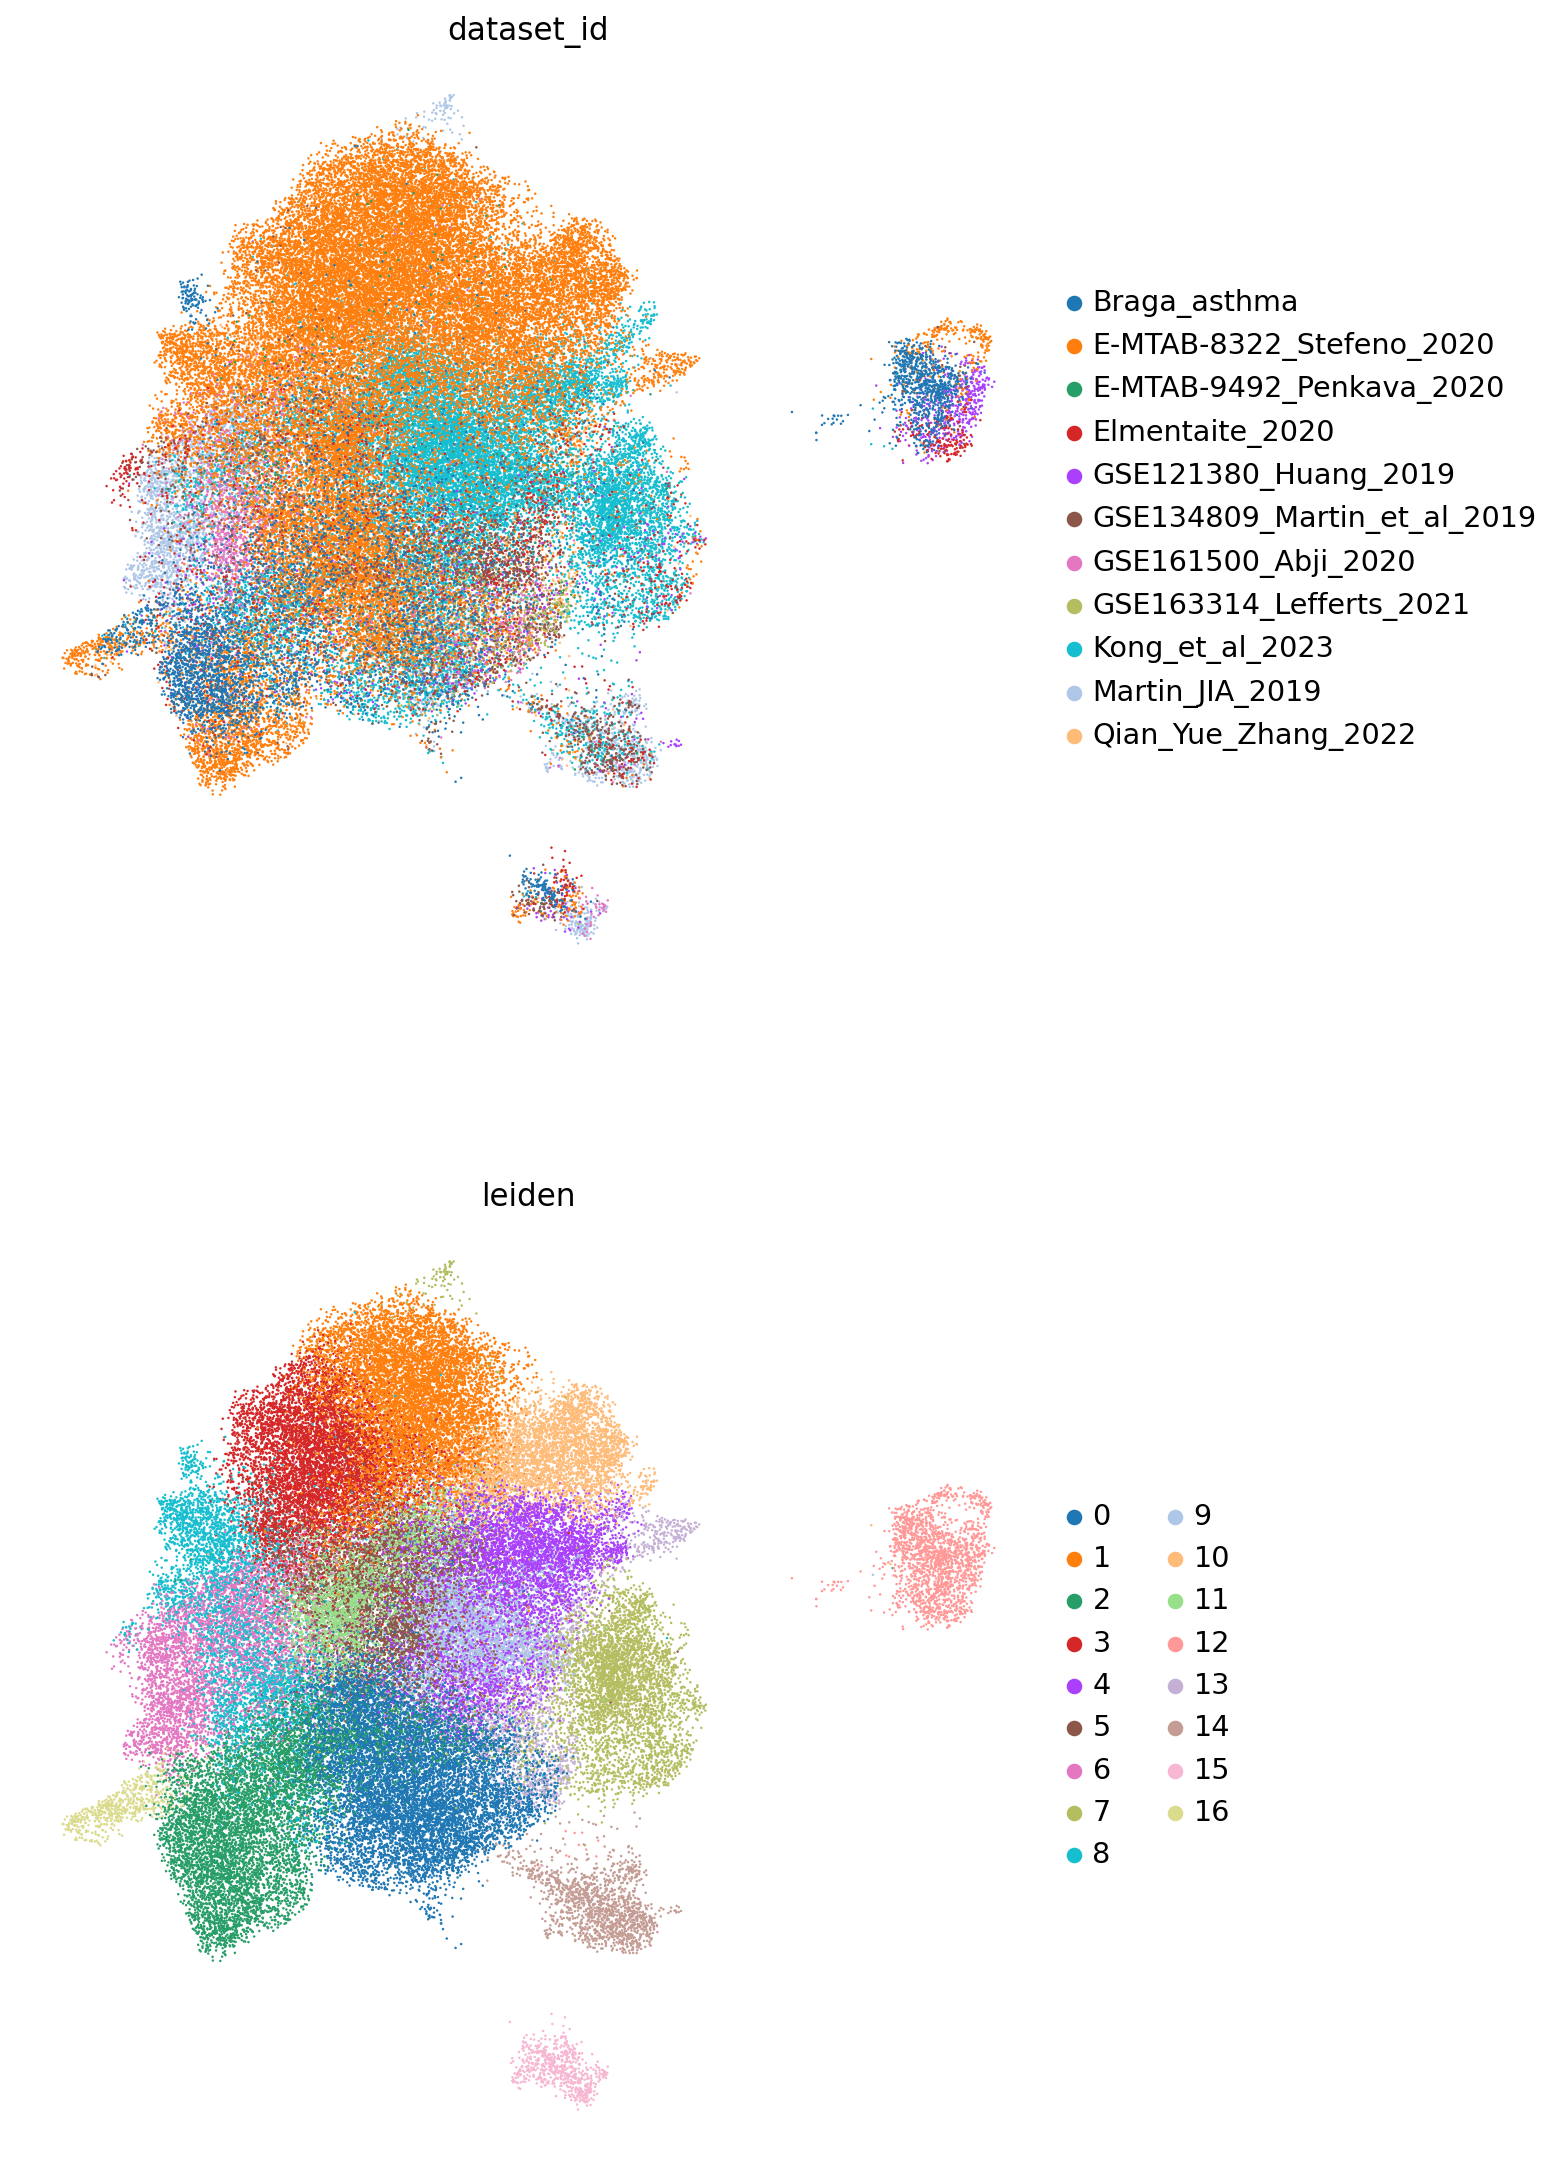

Plot UMAP of the full adata...


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


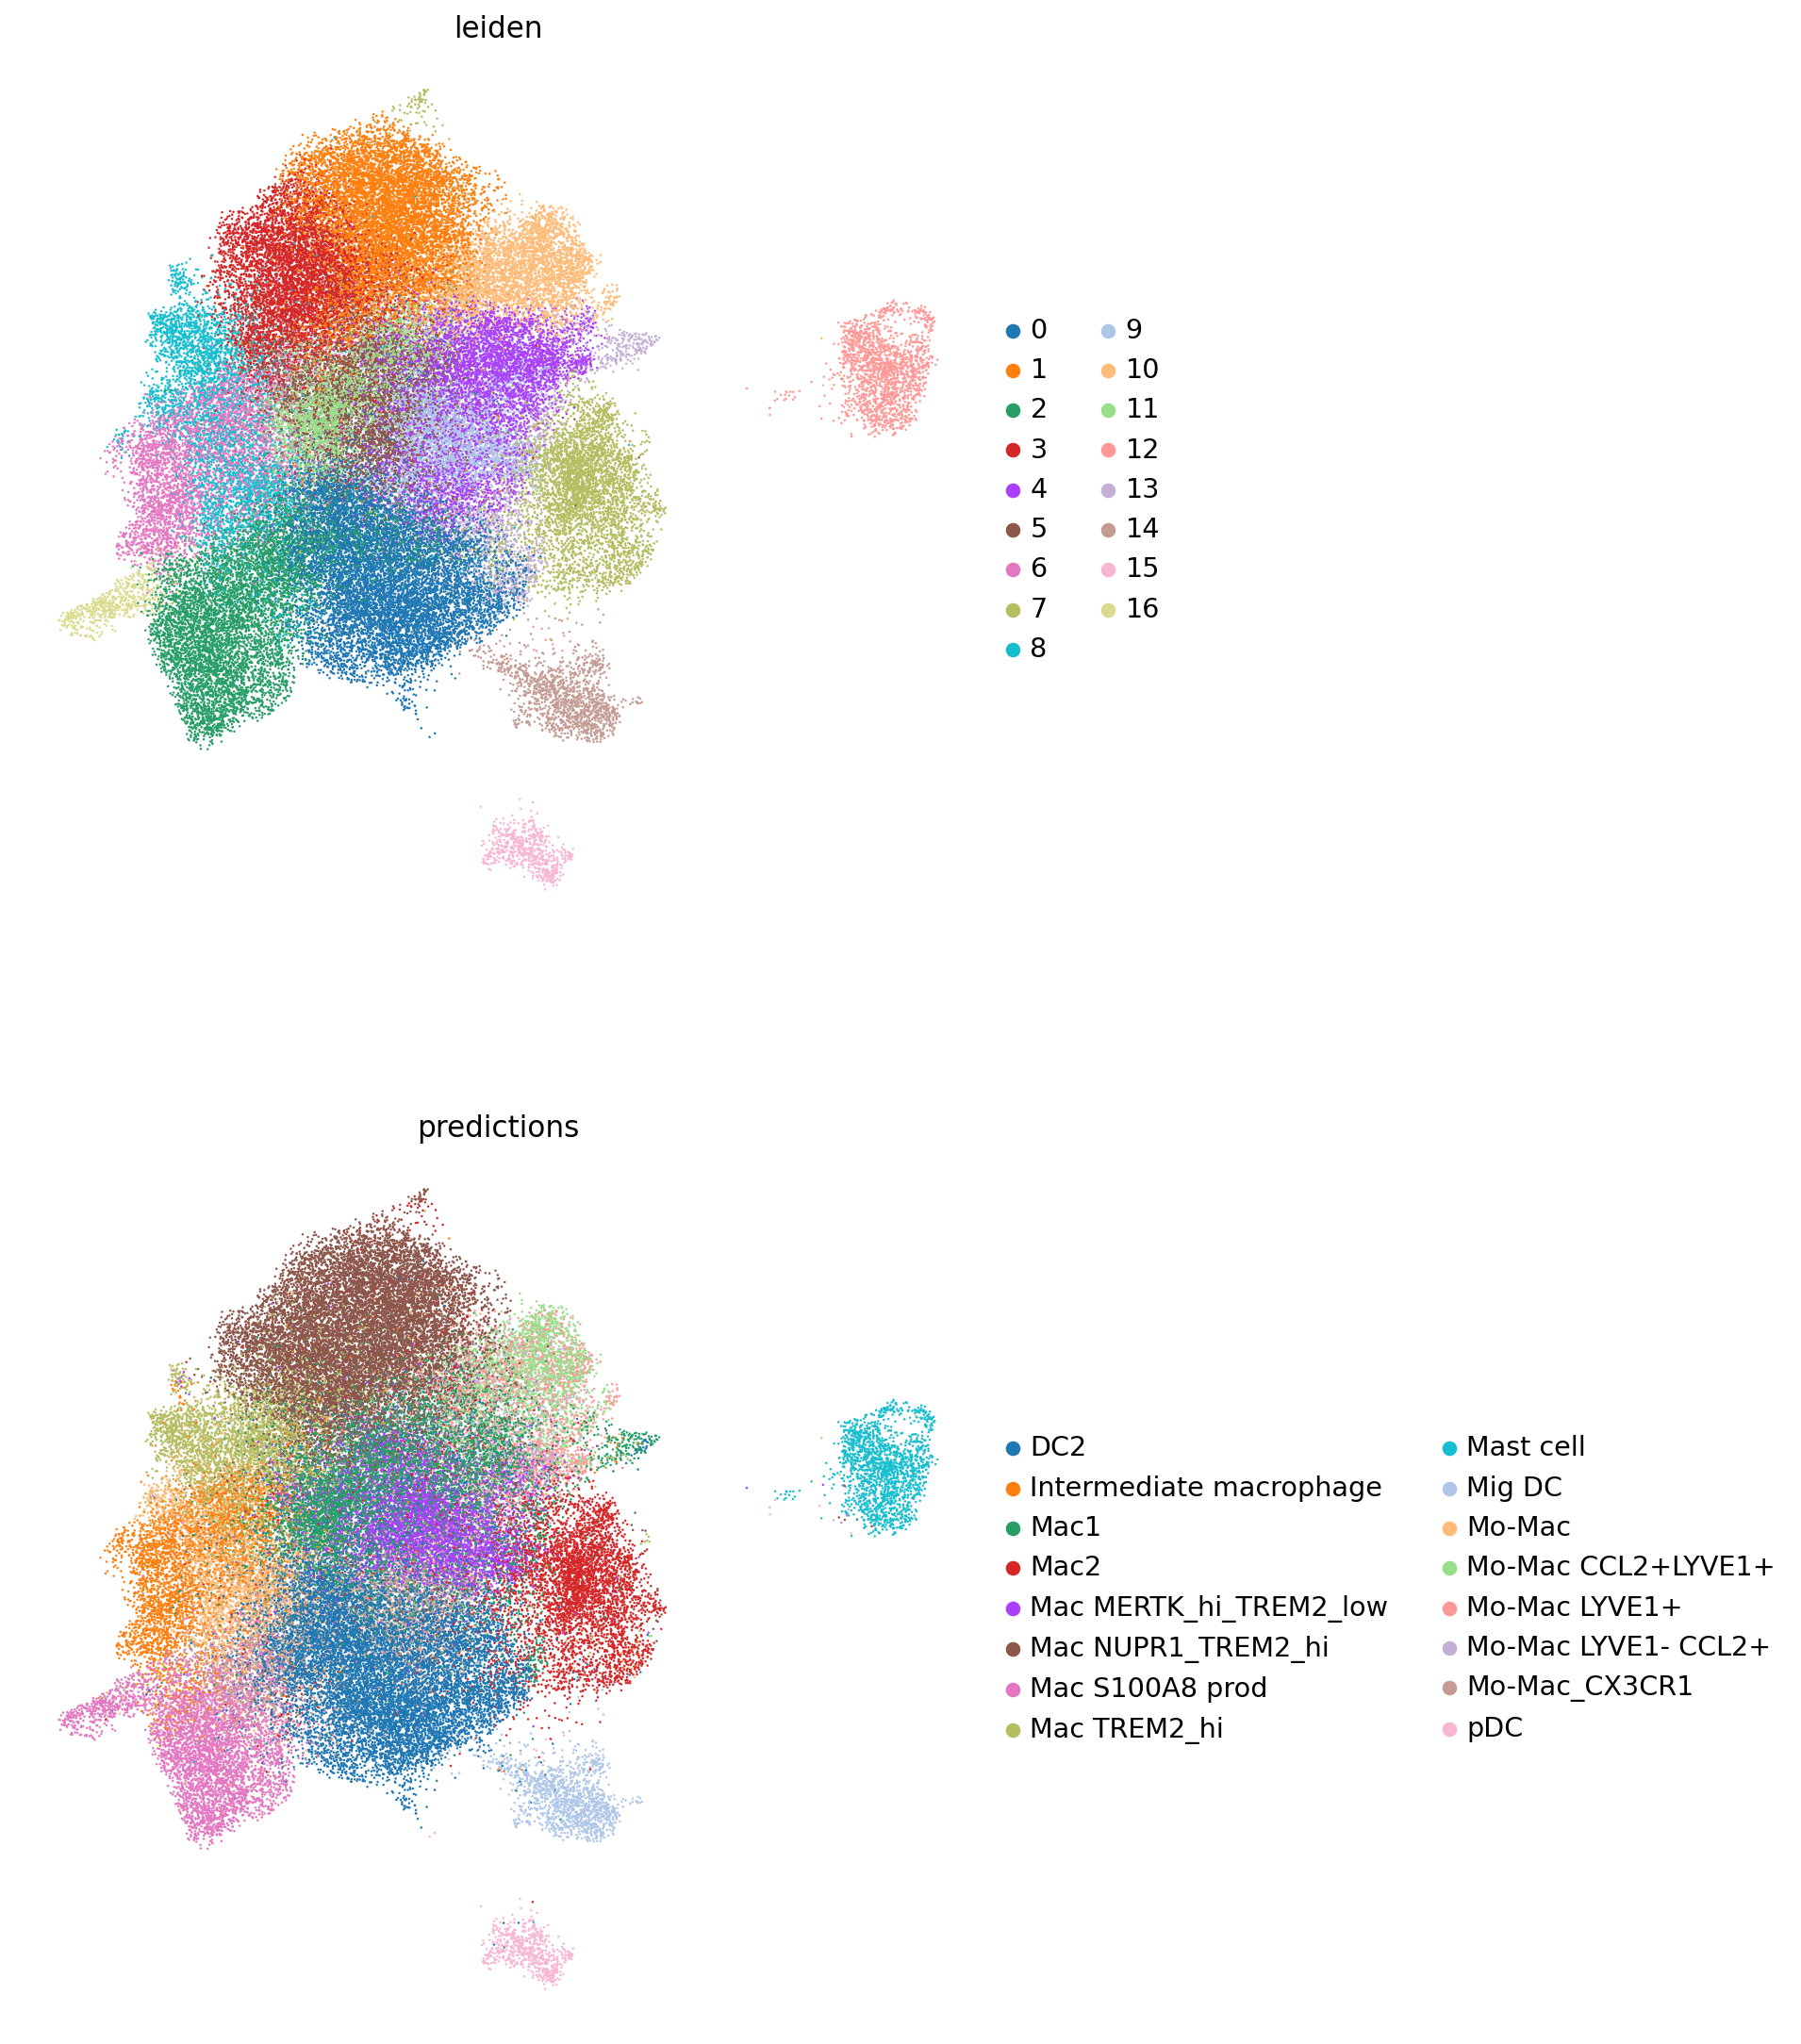

In [26]:
adata_myeloid = reintegrate_subset(adata=adata_myeloid, n_hgv=2000, n_layers=3)

In [27]:
adata_myeloid.obs['Cell_type_scANVI2'] = adata_myeloid.obs.predictions

<Axes: xlabel='Cell_type_scANVI', ylabel='Cell_type_scANVI2'>

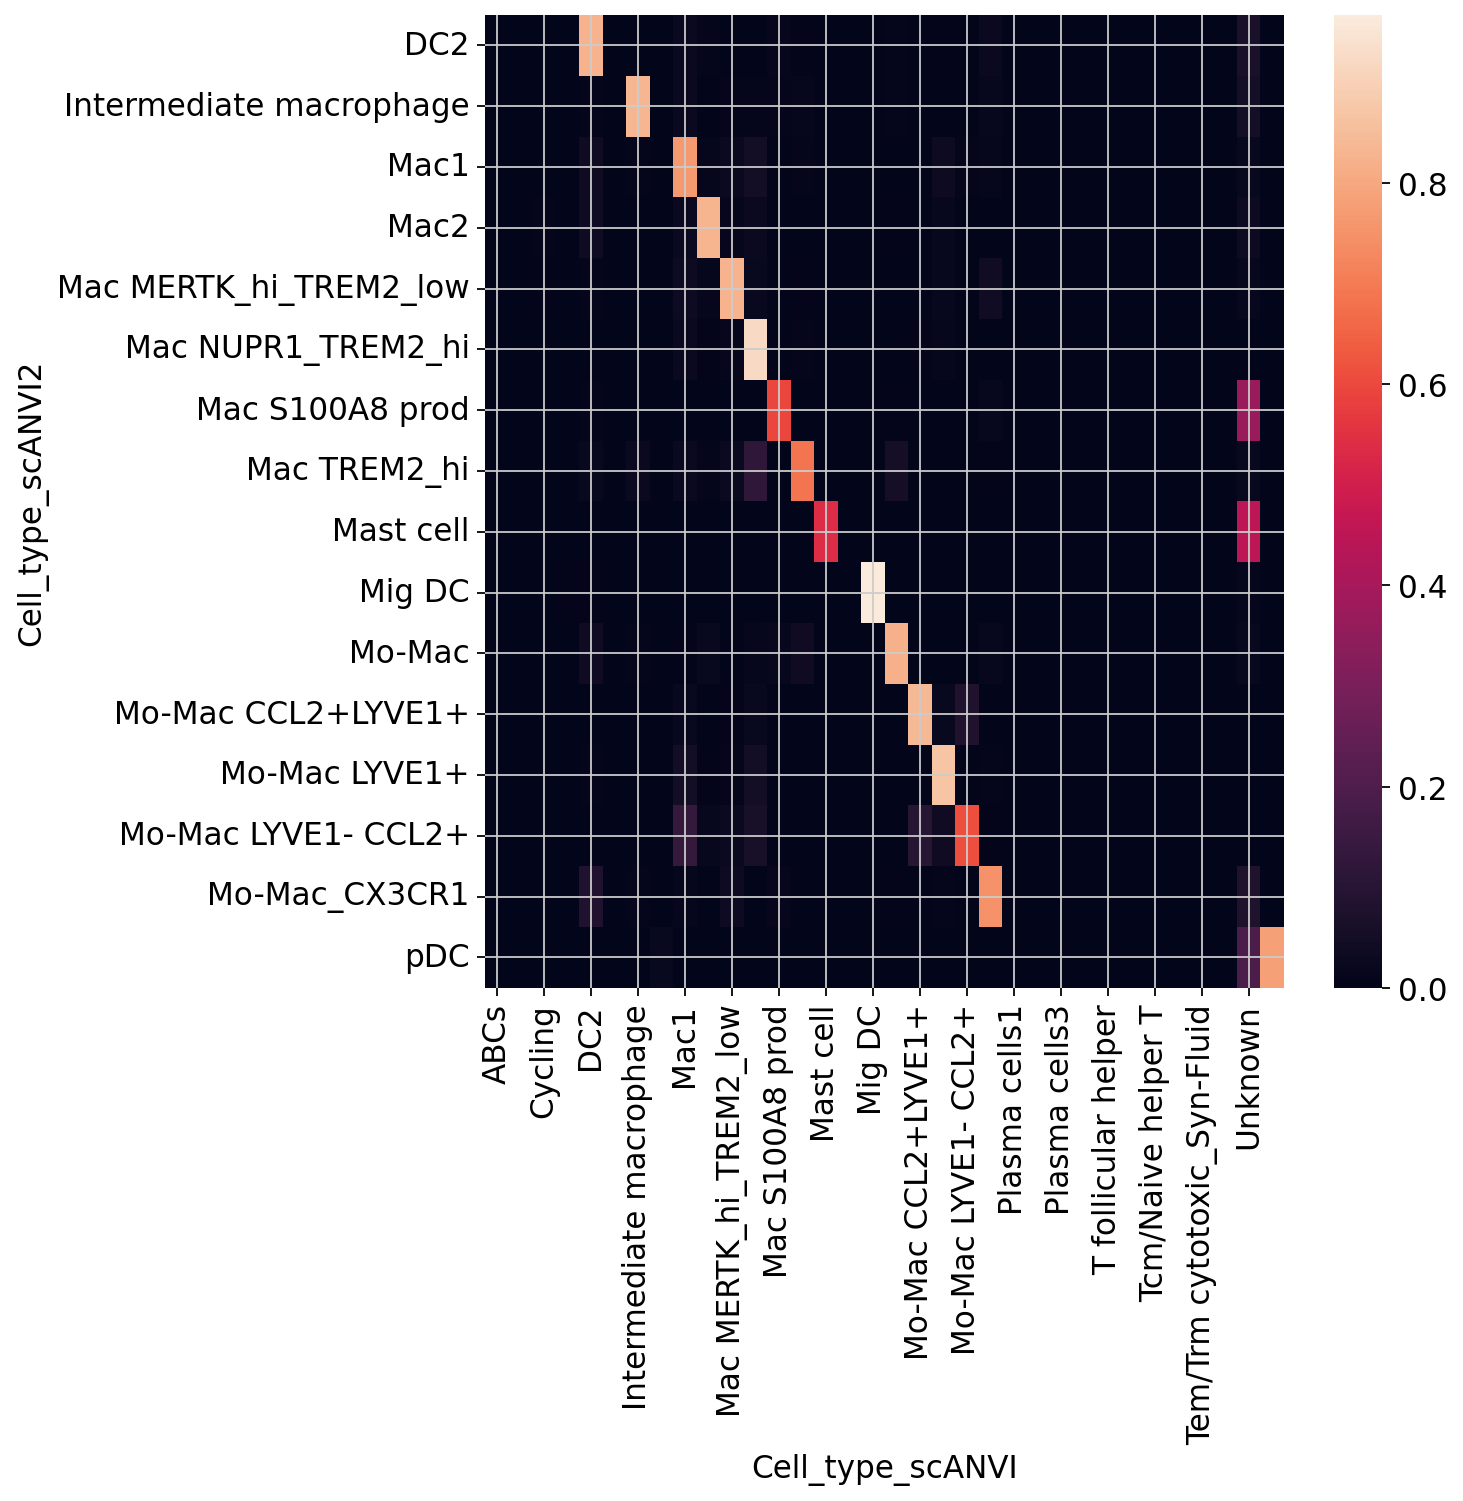

In [28]:
cmtx = sc.metrics.confusion_matrix("Cell_type_scANVI2", "Cell_type_scANVI", adata_myeloid.obs)
sns.heatmap(cmtx)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


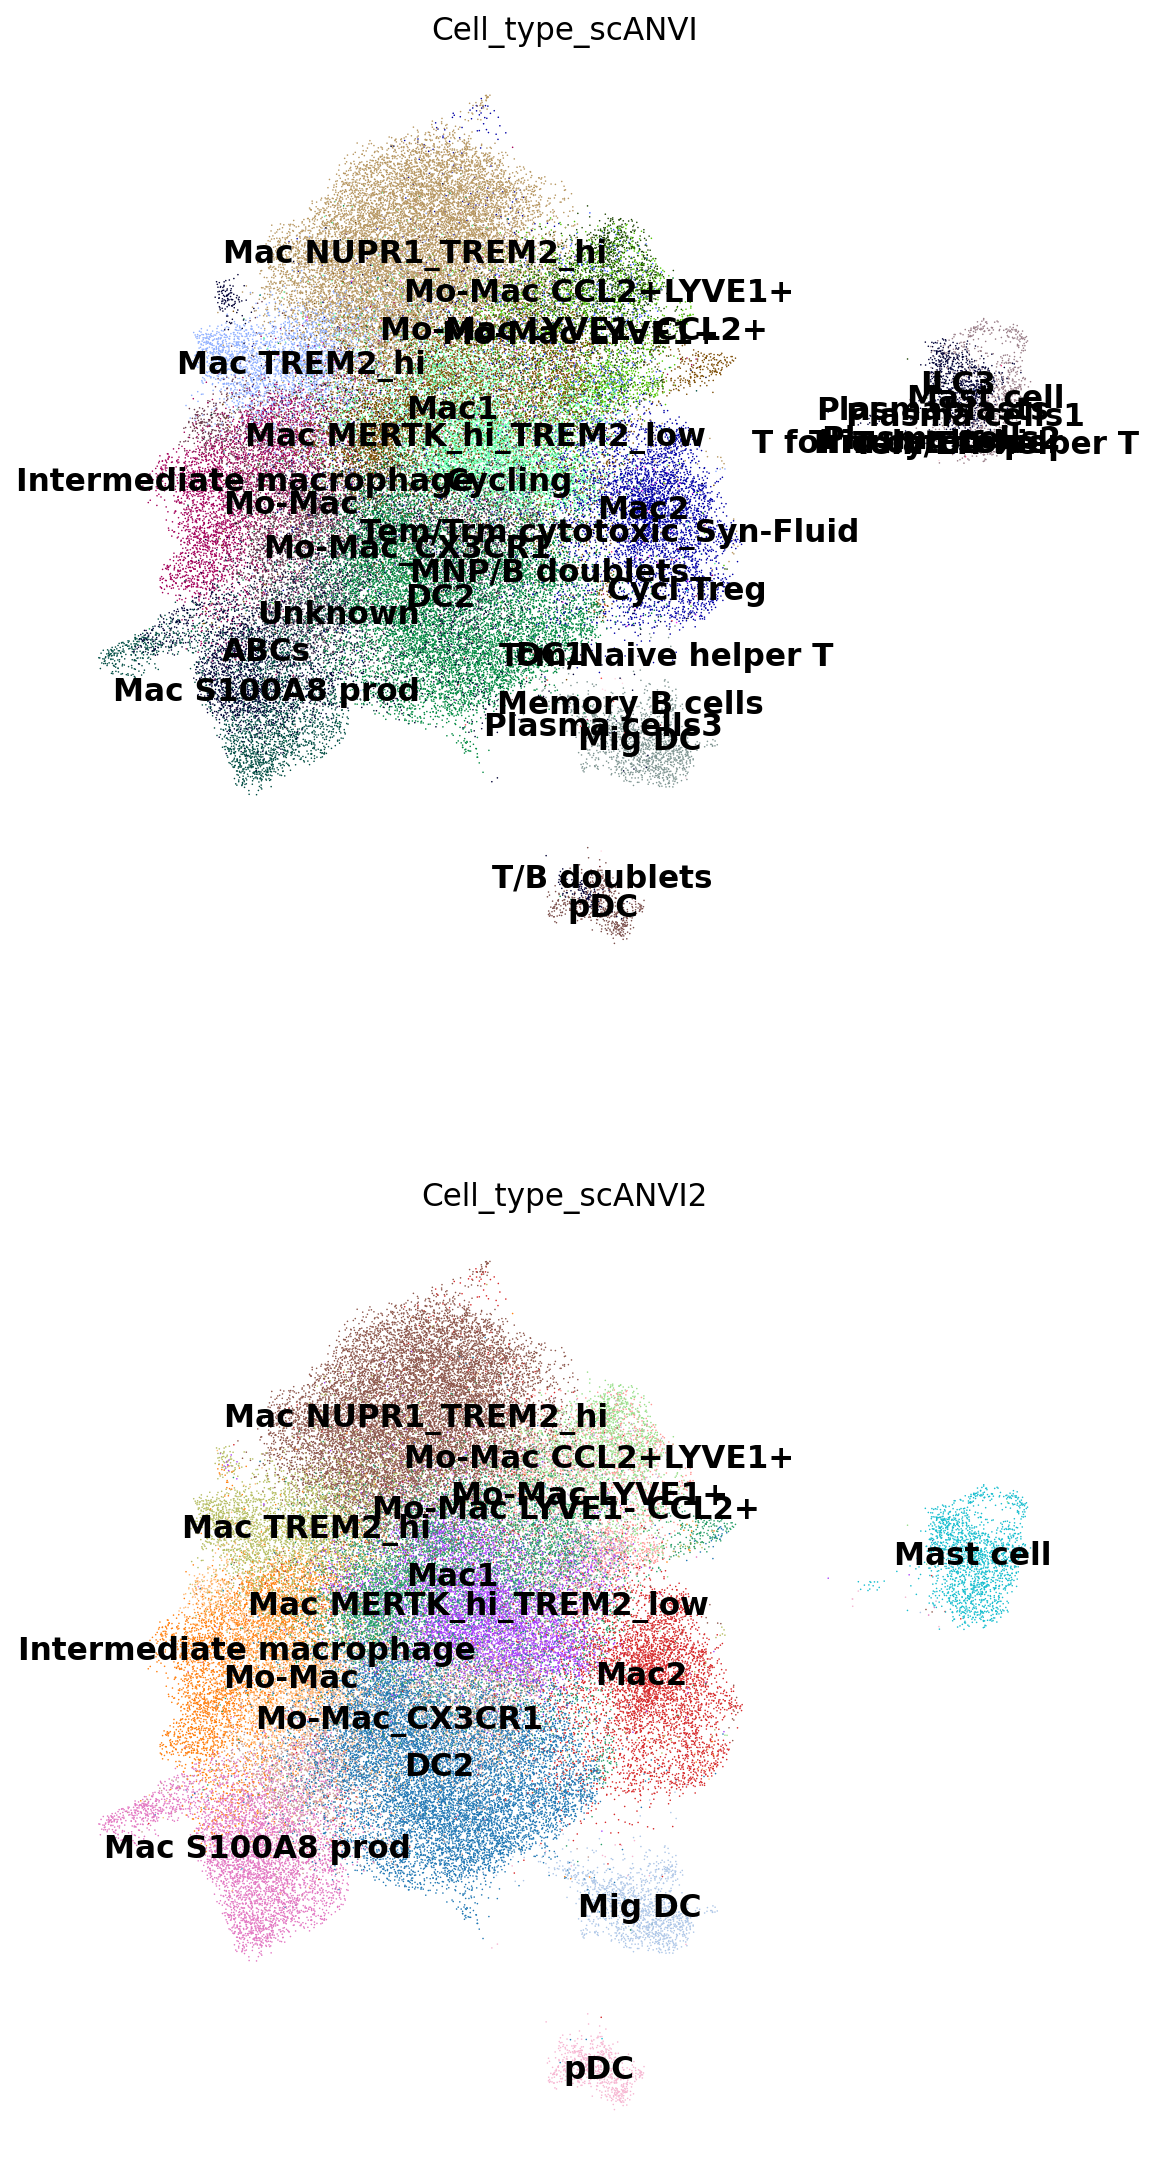

In [29]:
sc.pl.umap(
    adata_myeloid,
    color=['Cell_type_scANVI', 'Cell_type_scANVI2'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    legend_loc="on data"
)

In [30]:
adata_myeloid.obs = adata_myeloid.obs[['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2',
       'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source',
       'n_counts', 'doublet_scores', 'predicted_labels', 'over_clustering',
       'main_predicted_cell_groups', 'leiden', 'ref_query',
       'disease_label_trans', 'predictions', 'Cell_type_scANVI2']]

In [31]:
adata_myeloid.write_h5ad("result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/Myeloid_From_Tissue_Subset_with_asthma.h5ad")

In [32]:
del adata_myeloid
gc.collect()

84617

### T cell

In [21]:
adata.obs["predictions"].value_counts()

Tem/Trm cytotoxic              28339
Trm cytotoxic                  25697
Naive B cells                  23227
Th17                           20589
Tem/Eff helper T               19350
Th1                            17014
T regs                         16338
Memory B cells                 13977
T follicular helper            13388
Mac NUPR1_TREM2_hi             12585
Tcm/Naive helper T             12369
DC2                            11576
Plasma cells2                  10688
Plasma cells3                  10569
γδ T cells                      8704
Mac1                            7629
Mac MERTK_hi_TREM2_low          7104
NK_CD56bright                   6751
Trm_gut                         6733
Proliferative GC B cells        6663
MAIT cell                       6151
Plasma cells1                   5798
Tcm/Naive cytotoxic T cells     5207
Mac2                            5182
GC B cells1                     4975
Th1/Th17_gut                    4621
Intermediate macrophage         4611
M

In [22]:
adata_t_cell = adata[adata.obs.predictions.isin(['Tem/Trm cytotoxic', 'Trm cytotoxic', 'Th17', 'Th1',
                                                 'Tem/Eff helper T', 'T regs', 'T follicular helper', 'Tcm/Naive helper T', 
                                                 'γδ T cells', 'NK_CD56bright', 'Trm_gut', 'MAIT cell', 'Tcm/Naive cytotoxic T cells', 'Th1/Th17_gut',
                                                 'Trm_γδ', 'Tem/Trm cytotoxic_Syn-Fluid', 'ILC3', 'CD8_ZNF683+', 'Cycl Treg', 'TCD4_CM/T_Naive_Syn-Fluid',
                                                 'Trm cytotoxic INFGhi', 'PD1 CD4 T cells', 'NK_CD16hi', 'CD4', 'Cycl CD8', 'Cycl NK'
                                                ])].copy()

In [ ]:
adata_t_cell = reintegrate_subset(adata=adata_t_cell, n_hgv=2000, n_layers=3)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/envs

Epoch 36/36: 100%|██████████| 36/36 [09:17<00:00, 15.41s/it, v_num=1, train_loss_step=688, train_loss_epoch=701]

`Trainer.fit` stopped: `max_epochs=36` reached.


Epoch 36/36: 100%|██████████| 36/36 [09:17<00:00, 15.47s/it, v_num=1, train_loss_step=688, train_loss_epoch=701]
KNN, UMAP, clustering ...


In [ ]:
adata_t_cell.obs['Cell_type_scANVI2'] = adata_t_cell.obs.predictions

In [ ]:
cmtx = sc.metrics.confusion_matrix("Cell_type_scANVI2", "Cell_type_scANVI", adata_t_cell.obs)
sns.heatmap(cmtx)

In [ ]:
sc.pl.umap(
    adata_t_cell,
    color=['Cell_type_scANVI', 'Cell_type_scANVI2'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    legend_loc="on data"
)

In [ ]:
adata_t_cell.obs = adata_t_cell.obs[['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2',
       'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source',
       'n_counts', 'doublet_scores', 'predicted_labels', 'over_clustering',
       'main_predicted_cell_groups', 'leiden', 'ref_query',
       'disease_label_trans', 'predictions', 'Cell_type_scANVI2']]

In [ ]:
adata_t_cell.write_h5ad("result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/T_cells_From_Tissue_Subset_with_asthma.h5ad")

In [32]:
del adata_t_cell
gc.collect()

84617

### B cell

In [21]:
adata.obs["predictions"].value_counts()

Tem/Trm cytotoxic              28339
Trm cytotoxic                  25697
Naive B cells                  23227
Th17                           20589
Tem/Eff helper T               19350
Th1                            17014
T regs                         16338
Memory B cells                 13977
T follicular helper            13388
Mac NUPR1_TREM2_hi             12585
Tcm/Naive helper T             12369
DC2                            11576
Plasma cells2                  10688
Plasma cells3                  10569
γδ T cells                      8704
Mac1                            7629
Mac MERTK_hi_TREM2_low          7104
NK_CD56bright                   6751
Trm_gut                         6733
Proliferative GC B cells        6663
MAIT cell                       6151
Plasma cells1                   5798
Tcm/Naive cytotoxic T cells     5207
Mac2                            5182
GC B cells1                     4975
Th1/Th17_gut                    4621
Intermediate macrophage         4611
M

In [22]:
adata_b_cell = adata[adata.obs.predictions.isin(['Naive B cells', 'Memory B cells', 'Plasma cells2', 'Plasma cells3', 'Proliferative GC B cells',
                                                                      'Plasma cells1', 'GC B cells1', 'T/B doublets', 'ABCs', 
                                                                      'Plasmablasts', 'MNP/B doublets', 'IgM plasma cells'])].copy()

In [28]:
adata_b_cell.obs.dataset_id.value_counts()

GSE121380_Huang_2019           23291
Qian_Yue_Zhang_2022            20013
Elmentaite_2020                17994
GSE134809_Martin_et_al_2019    16761
GSE163314_Lefferts_2021         3076
Braga_asthma                    1359
E-MTAB-8322_Stefeno_2020        1042
Kong_et_al_2023                   11
Martin_JIA_2019                    1
Name: dataset_id, dtype: int64

In [30]:
adata_b_cell = adata_b_cell[adata_b_cell.obs.dataset_id != "Martin_JIA_2019"]


In [ ]:
adata_b_cell = reintegrate_subset(adata=adata_b_cell, n_hgv=2000, n_layers=3)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_dataframe_field.py:183: UserWarning: Category 32 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categ

Epoch 72/96:  74%|███████▍  | 71/96 [06:55<02:29,  5.98s/it, v_num=1, train_loss_step=655, train_loss_epoch=653]

In [ ]:
adata_b_cell.obs['Cell_type_scANVI2'] = adata_b_cell.obs.predictions

In [ ]:
cmtx = sc.metrics.confusion_matrix("Cell_type_scANVI2", "Cell_type_scANVI", adata_b_cell.obs)
sns.heatmap(cmtx)

In [ ]:
sc.pl.umap(
    adata_b_cell,
    color=['Cell_type_scANVI', 'Cell_type_scANVI2'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    legend_loc="on data"
)

In [ ]:
adata_b_cell.obs = adata_b_cell.obs[['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2',
       'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source',
       'n_counts', 'doublet_scores', 'predicted_labels', 'over_clustering',
       'main_predicted_cell_groups', 'leiden', 'ref_query',
       'disease_label_trans', 'predictions', 'Cell_type_scANVI2']]

In [ ]:
adata_b_cell.write_h5ad("result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/B_cells_From_Tissue_Subset_with_asthma.h5ad")

### Save 

In [45]:
def save_x_scvi(adata,data_dir, file_name, vae):
    """
    data_dir path to save scvi embedding
    file_name name for example Immune_compartment_PBMC
    """
   # x_scanvi = vae.get_latent_representation(adata)
    outname = "{fname}.scVI_out.npy".format(fname=file_name)
    #modelname = "{fname}_scvi_model".format(fname=file_name)
    #np.save(data_dir + outname, x_scanvi)
    #vae.save(data_dir + modelname, overwrite=True)
    #pd.DataFrame(adata.obs).to_csv(data_dir+outname+".obs.csv")
    np.save(data_dir + file_name+".UMAP.npy", adata.obsm["X_umap"])
    
    #umap and obs as df
    
    umap = adata.obsm["X_umap"]
    
    umap = pd.DataFrame(umap, columns=["umap1", "umap2"])
    obs = adata.obs
    umap.index = obs.index
    obs["umap1"] = umap.umap1
    obs["umap2"] = umap.umap2
    obs.to_csv("Obs_umap_" + file_name + "scVI_from_gpu.csv")

In [ ]:
adata = sc.read_h5ad('Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [46]:
 save_x_scvi(adata=adata, data_dir="result_scvi/Myeloid_B_T_From_Tissue/", file_name="scVI_Myeloid_B_T_From_Tissue", vae=vae)

In [47]:
umap = adata.obsm["X_umap"]

In [48]:
umap = pd.DataFrame(umap, columns=["umap1", "umap2"])

In [49]:
umap

,umap1,umap2
0,0.122970,13.952169
1,0.282985,8.415564
2,-0.288593,8.597524
3,-0.630980,14.753313
4,1.085140,7.814439
...,...,...
365198,1.350270,-0.496049
365199,1.450526,-2.180768
365200,0.323231,0.026419
365201,0.572630,-0.601193


In [50]:
obs = adata.obs

In [51]:
umap.index = obs.index

In [52]:
obs["umap1"] = umap.umap1

obs["umap2"] = umap.umap2

In [53]:
obs.umap1

AAACCTGGTAGCACGA-1-1_0_0-0-0                  0.122970
AAACCTGGTCCGAGTC-1_0_0-0-0                    0.282985
AAACCTGTCAGTTAGC-1_0_0-0-0                   -0.288593
AAAGATGTCCTAAGTG-1-1_0_0-0-0                 -0.630980
AAAGCAATCTACGAGT-1_0_0-0-0                    1.085140
                                                ...   
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-2    1.350270
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-2    1.450526
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-2    0.323231
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-2    0.572630
TTTGTCAGTGATGCCC-1-1-1-1-1-1-1_1_0_0-1-1-2    0.803131
Name: umap1, Length: 365203, dtype: float32

In [54]:
obs.to_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv")

In [55]:
obs

,tissue,disease,donor_id,dataset_id,sex,development_stage,batch,majority_voting,conf_score,_scvi_batch,...,disease_tissue,cell_type2,majority_voting_2,leiden_2,leiden_3,relabeled_cells_2,relabeled_cells_3,leiden,umap1,umap2
AAACCTGGTAGCACGA-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.947648,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,6,0.122970,13.952169
AAACCTGGTCCGAGTC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.963530,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,2,0.282985,8.415564
AAACCTGTCAGTTAGC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.912090,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,2,-0.288593,8.597524
AAAGATGTCCTAAGTG-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.989998,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,6,-0.630980,14.753313
AAAGCAATCTACGAGT-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.775685,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,2,1.085140,7.814439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.422139,169,...,NaN,7,B_plasma_IgA,5,5,Th1,Th1,0,1.350270,-0.496049
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.398410,169,...,NaN,7,B_plasma_IgA,5,5,Th1,Th1,0,1.450526,-2.180768
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.421337,169,...,NaN,7,B_plasma_IgA,7,6,Th17,Th17,0,0.323231,0.026419
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.121884,169,...,NaN,"6,0",B_plasma_IgA,3,5,T follicular helper,T follicular helper,0,0.572630,-0.601193


In [56]:
!rclone copy Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv\
'gdrive:Projects/SCVI_Results/Milo_combine/'